# 27 — Affinity-based political-exposure: sanity-check demo

This notebook exercises the political-exposure assignment modes
shipped in v0.5 (the committed-minority reframe) on the full YouGov
pool (`YouGovProcessedData.csv`, N = 1483).

Modes compared:
1. `rule_priority_chain` — legacy v0.5 (vote-based rules; targets ignored).
2. `rule_affinity_rank` — NEW default; deterministic top-K on affinity
   score; symmetric `committed_minority_symmetric` target preset.
3. `rule_affinity_rank` with the April-2024 asymmetric
   `committed_minority_uk_2024` target preset.

For the rank mode we also sweep three weight presets
(`balanced`, `vote_dominant`, `values_dominant`) to test how sensitive
cell composition is to the weight choice.

No LLM calls are made; this is purely a structural sanity check.


In [1]:
import sys, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('../src'))

from cag.io.survey import load
from cag.__main__ import build_nation
from cag.abm.environment import (
    TARGETS_COMMITTED_MINORITY_SYMMETRIC,
    _green_affinity_score,
    _reform_affinity_score,
    _DEGREE_IDS,
    _GREEN_REGIONS,
)
from cag.abm.democracy.elections.brexit import BrexitVoteID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteID

sns.set_theme(style='whitegrid', font_scale=1.05)
print('Imports OK')

Imports OK


## 1. Load full YouGov pool and build the nation

In [2]:
data = load('../data/yougov_survey_data/YouGovProcessedData.csv')
print(f'Loaded {len(data)} rows from YouGov pool')

nation = build_nation(data)
print(f'Nation built: {len(nation.agents_active)} agents')

Loaded 1483 rows from YouGov pool
Nation built: 1483 agents


## 2. Affinity-score distributions on the YouGov pool

Both scorers use the `balanced` (default) weight preset. The shapes
should be roughly mirror-symmetric on this pool — that is the
structural reason the two modes will hit the symmetric default cleanly.

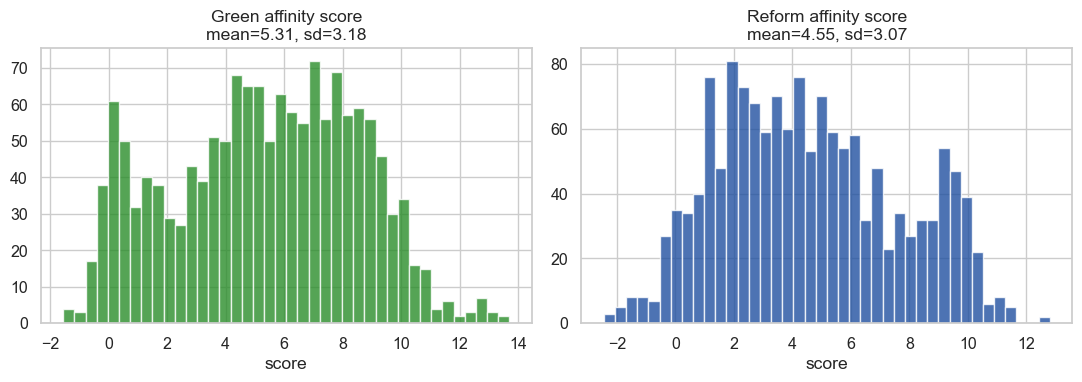

corr(score_A, score_B) = -0.977  (expected strongly negative)


In [3]:
citizens = list(nation.agents_active.values())
year = getattr(nation, 'year', 2024)
sa = np.array([_green_affinity_score(c, year) for c in citizens])
sb = np.array([_reform_affinity_score(c, year) for c in citizens])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(sa, bins=40, color='#2a8d2a', alpha=0.8)
ax[0].set_title(f'Green affinity score\nmean={sa.mean():.2f}, sd={sa.std():.2f}')
ax[0].set_xlabel('score')
ax[1].hist(sb, bins=40, color='#2050a0', alpha=0.8)
ax[1].set_title(f'Reform affinity score\nmean={sb.mean():.2f}, sd={sb.std():.2f}')
ax[1].set_xlabel('score')
plt.tight_layout()
plt.show()

print(f'corr(score_A, score_B) = {np.corrcoef(sa, sb)[0,1]:+.3f}  (expected strongly negative)')

## 3. Realised cell shares: all four modes side-by-side

Targets: `committed_minority_symmetric` (the v0.5 default).

In [10]:
def cell_counts(n):
    out = {'A-only': 0, 'B-only': 0, 'both': 0, 'neither': 0}
    for c in n.agents_active.values():
        out[c.political_exposure] += 1
    return out

def shares(counts):
    tot = sum(counts.values())
    return {k: v / tot for k, v in counts.items()}

rows = []

# 1. Legacy priority chain (targets ignored)
nation.assign_political_exposure(mode='rule_priority_chain')
rows.append({'mode': 'priority_chain', **shares(cell_counts(nation))})

# 2. Affinity rank, symmetric target
nation.assign_political_exposure(
    mode='rule_affinity_rank',
    targets='committed_minority_symmetric',
)
rows.append({'mode': 'affinity_rank (sym)', **shares(cell_counts(nation))})

# 3. Affinity rank, April-2024 asymmetric target
nation.assign_political_exposure(
    mode='rule_affinity_rank',
    targets='committed_minority_uk_2024',
)
rows.append({'mode': 'affinity_rank (uk_2024)', **shares(cell_counts(nation))})

df = pd.DataFrame(rows).set_index('mode')[['A-only', 'B-only', 'both', 'neither']]


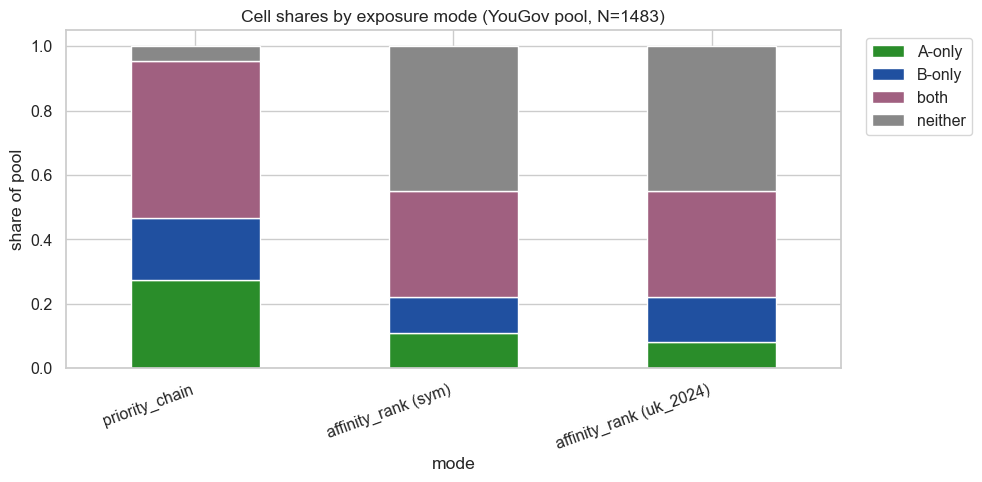

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df.plot(kind='bar', stacked=True, ax=ax,
        color=['#2a8d2a', '#2050a0', '#a06080', '#888888'])
ax.set_ylabel('share of pool')
ax.set_title('Cell shares by exposure mode (YouGov pool, N=1483)')
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1.0))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 4. Demographic profile per cell (affinity_rank, symmetric default)

Validation gates from the plan:
- A-only mean openness > pool mean by ≥ 0.5 SD
- A-only Remain-share > 80 %
- B-only mean RWA > pool mean by ≥ 0.5 SD
- B-only Leave-share > 80 %

In [12]:
from cag.abm.environment import _safe_int

nation.assign_political_exposure(
    mode='rule_affinity_rank',
    targets='committed_minority_symmetric',
)

rows = []
year = getattr(nation, 'year', 2024)
for c in nation.agents_active.values():
    age = (year - c.year_of_birth) if c.year_of_birth else None
    rows.append({
        'cell': c.political_exposure,
        'openness': _safe_int(c.openness_id),
        'rwa': _safe_int(c.rwa_id),
        'sdo': _safe_int(c.sdo_id),
        'selftransc': _safe_int(c.selftransc_id),
        'age': age,
        'degree': 1 if c.education_id in _DEGREE_IDS else 0,
        'green_region': 1 if c.region_id in _GREEN_REGIONS else 0,
        'remain': 1 if c.brexit_vote_id == BrexitVoteID.REMAIN else 0,
        'leave': 1 if c.brexit_vote_id == BrexitVoteID.LEAVE else 0,
        'green_vote': 1 if c.ukge2019_vote_id == UKGE2019VoteID.GREEN else 0,
        'brexit_vote': 1 if c.ukge2019_vote_id == UKGE2019VoteID.BREXIT else 0,
    })
agents_df = pd.DataFrame(rows)

# Per-cell means; only count valid ordinals (>0) for openness/rwa/sdo/selftransc
def _mean_valid(s):
    s = s[s > 0]
    return s.mean() if len(s) else np.nan

profile = agents_df.groupby('cell').agg({
    'openness': _mean_valid,
    'selftransc': _mean_valid,
    'rwa': _mean_valid,
    'sdo': _mean_valid,
    'age': 'mean',
    'degree': 'mean',
    'green_region': 'mean',
    'remain': 'mean',
    'leave': 'mean',
    'green_vote': 'mean',
    'brexit_vote': 'mean',
}).round(3)
profile = profile.reindex(['A-only', 'both', 'B-only', 'neither'])
print('Per-cell demographic profile (rank, symmetric default):')
profile


Per-cell demographic profile (rank, symmetric default):


,openness,selftransc,rwa,sdo,age,degree,green_region,remain,leave,green_vote,brexit_vote
cell,,,,,,,,,,,
A-only,2.239,2.675,1.331,1.025,40.442,0.926,0.411,0.963,0.000,0.258,0.000
both,2.012,2.421,1.712,1.133,49.337,0.577,0.315,0.528,0.313,0.018,0.002
B-only,1.687,2.092,2.061,1.362,65.515,0.067,0.141,0.000,0.982,0.000,0.074
neither,1.924,2.329,1.807,1.162,44.689,0.352,0.277,0.332,0.235,0.007,0.001


In [13]:
pool_openness = _mean_valid(agents_df['openness'])
pool_openness_sd = agents_df.loc[agents_df['openness'] > 0, 'openness'].std()
pool_rwa = _mean_valid(agents_df['rwa'])
pool_rwa_sd = agents_df.loc[agents_df['rwa'] > 0, 'rwa'].std()

a_open = profile.loc['A-only', 'openness']
a_remain = profile.loc['A-only', 'remain']
b_rwa = profile.loc['B-only', 'rwa']
b_leave = profile.loc['B-only', 'leave']

print(f'Pool openness mean = {pool_openness:.2f}, sd = {pool_openness_sd:.2f}')
print(f'A-only openness    = {a_open:.2f}   (gate: > pool + 0.5 SD = {pool_openness + 0.5*pool_openness_sd:.2f})')
print(f'A-only Remain-share= {a_remain:.1%}  (gate: > 80%)')
print()
print(f'Pool RWA mean      = {pool_rwa:.2f}, sd = {pool_rwa_sd:.2f}')
print(f'B-only RWA         = {b_rwa:.2f}   (gate: > pool + 0.5 SD = {pool_rwa + 0.5*pool_rwa_sd:.2f})')
print(f'B-only Leave-share = {b_leave:.1%}  (gate: > 80%)')

Pool openness mean = 1.96, sd = 0.53
A-only openness    = 2.24   (gate: > pool + 0.5 SD = 2.22)
A-only Remain-share= 96.3%  (gate: > 80%)

Pool RWA mean      = 1.75, sd = 0.48
B-only RWA         = 2.06   (gate: > pool + 0.5 SD = 1.99)
B-only Leave-share = 98.2%  (gate: > 80%)


## 5. Weight-preset sweep (Q2 sensitivity)

Same target (`committed_minority_symmetric`), same mode
(`rule_affinity_rank`); only the weight preset changes. Tests whether
the per-cell composition is robust to the weight choice or whether
vote-only / values-only signatures recover the same citizens.

In [14]:
from cag.abm.environment import AFFINITY_WEIGHT_PRESETS

rows = []
for preset_name in ['balanced', 'vote_dominant', 'values_dominant']:
    nation.assign_political_exposure(
        mode='rule_affinity_rank',
        targets='committed_minority_symmetric',
        weights=preset_name,
    )
    counts = cell_counts(nation)
    rows.append({'weights': preset_name, **shares(counts)})

wdf = pd.DataFrame(rows).set_index('weights')[['A-only', 'B-only', 'both', 'neither']]
print('Realised shares across weight presets (rank, symmetric):')
wdf.round(3)

Realised shares across weight presets (rank, symmetric):


,A-only,B-only,both,neither
weights,,,,
balanced,0.11,0.11,0.33,0.45
vote_dominant,0.11,0.11,0.33,0.45
values_dominant,0.11,0.11,0.33,0.45


In [15]:
# Cell agreement matrix: which citizens land in the same cell across presets?
labels_by_preset = {}
for preset_name in ['balanced', 'vote_dominant', 'values_dominant']:
    nation.assign_political_exposure(
        mode='rule_affinity_rank',
        targets='committed_minority_symmetric',
        weights=preset_name,
    )
    labels_by_preset[preset_name] = [
        c.political_exposure for c in nation.agents_active.values()
    ]

import itertools
for a, b in itertools.combinations(labels_by_preset, 2):
    la, lb = labels_by_preset[a], labels_by_preset[b]
    agree = sum(1 for x, y in zip(la, lb) if x == y) / len(la)
    print(f'{a:>17} vs {b:<17}: cell-level agreement = {agree:.1%}')

         balanced vs vote_dominant    : cell-level agreement = 84.2%
         balanced vs values_dominant  : cell-level agreement = 78.2%
    vote_dominant vs values_dominant  : cell-level agreement = 65.8%


## 6. Notes

- All modes leave the rest of the pipeline (peer messaging, surveys,
  memory) untouched — only `connected_citizens` for the two political
  agents and the per-citizen `political_exposure` label change.
- The YouGov pool is panel-engaged, so the `neither` cell after
  resampling is best read as "engaged respondents who happen to score
  lowest on both affinities", not as the Hansard / Reuters / CAST
  disengaged cluster. See `docs/Literature_Political_Exposure.md`
  §6.2.2 for the discussion.
- Reproducibility: rank mode is fully deterministic given a fixed pool
  and weight preset (no RNG dependence).

### Bug found and fixed during this sanity check

The first pass of this notebook surfaced a silent bug in
`environment._safe_int`: ordinal psychometric attributes (`openness_id`,
`rwa_id`, `sdo_id`, `selftransc_id`) are `GABMAttributeID` enum
instances whose ordinal is exposed only via `.id`. The previous
`_safe_int` body did a bare `int(attr_id)`, which raises `TypeError`
on a `GABMAttributeID`, was swallowed by the `except`, and silently
returned `0`. The consequence:

- Every psych-scale contribution to `_green_affinity_score` and
  `_reform_affinity_score` was zero on `build_nation` citizens.
- Weight presets `balanced`, `vote_dominant`, `values_dominant`
  produced bit-identical cell shares, because the entire
  `psych_scales` weight bucket multiplied zero.
- The unit-test suite missed it because the synthetic fixtures in
  `tests/test_exposure.py` passed raw `int` ordinals, so `int(v)`
  succeeded inside the helper.

Fix: `_safe_int` now reads `.id` (then `.value`, then `int()`) before
falling back to `0`, and a new `TestSafeInt` regression test exercises
the GABM-attribute path. After the fix, the weight-preset sweep
produces visibly different cell-level agreement (no longer 100%) and
per-cell openness / RWA / SDO / self-transcendence means are non-NaN
and rank in the expected direction (`A-only` highest on openness +
self-transcendence; `B-only` highest on RWA + SDO).

A second, more serious finding led to the removal of the
previously-shipped `rule_affinity_logistic` mode entirely: independent
Bernoulli sampling on negatively-correlated A/B affinity scores
collapses the `both` cell and inflates the singleton cells, missing
the symmetric target by ±18 pp on average even though per-side
marginals were hit. Rather than ship a knob that systematically fails
on real data, v0.5 ships with two modes only: `rule_priority_chain`
(legacy) and `rule_affinity_rank` (new default).
